In [1]:
!pip install -q --upgrade wandb

In [2]:
!pip install -q torchinfo

In [3]:
import os
import random

import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets
import torchvision.transforms as transforms

from torchinfo import summary

import wandb

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
datad = '/content/drive/MyDrive/СМАДИМО/ГП5/the_wildfire_dataset_2n_version'
splits = ['train', 'val', 'test']
classes = ['fire', 'nofire']

In [6]:
assert os.path.exists(datad), 'нет папки: ' + datad
for i in splits:
    path = os.path.join(datad, i)
    assert os.path.exists(path), 'нет выборки: ' + i
    print(i + ':', os.listdir(path))

train: ['fire', 'nofire']
val: ['fire', 'nofire']
test: ['fire', 'nofire']


## EDA

Проверим баланс классов и посчситаем количество изображений fire и nofire

In [7]:
imgext = ('.jpg', '.jpeg','.png')
counts = {}
for i in splits:
    counts[i] = {}
    print(i.upper())
    for j in classes:
        path = os.path.join(datad, i, j)
        files = [f for f in os.listdir(path) if f.lower().endswith(imgext)]
        counts[i][j] = len(files)
        print(j + ':', len(files))
    total = sum(counts[i].values())
    print('Всего:', total)
    for j in classes:
        share = counts[i][j] / total
        print('Доля {}: {:.2%}'.format(j, share))

TRAIN
fire: 730
nofire: 1157
Всего: 1887
Доля fire: 38.69%
Доля nofire: 61.31%
VAL
fire: 156
nofire: 246
Всего: 402
Доля fire: 38.81%
Доля nofire: 61.19%
TEST
fire: 159
nofire: 251
Всего: 410
Доля fire: 38.78%
Доля nofire: 61.22%


В трейне, тесте и валидации умеренный одинвковый баланс, fire это примерно 39 процентов выборки, nofire - примерно 61 процент

Посмотрим размеры, форматы и цветовые режимы изображений, убедимся, что в датасете нет повреждённых файлов

In [8]:
from collections import Counter
from PIL import Image

In [9]:
sizes = Counter()
formats = Counter()
modes = Counter()
broken = []
for i in splits:
    for j in classes:
        path = os.path.join(datad, i, j)
        files = [f for f in os.listdir(path) if f.lower().endswith(imgext)]
        for f in tqdm(files, desc=i + '/' + j):
            fp = os.path.join(path, f)
            try:
                with Image.open(fp) as img:
                    sizes[img.size] += 1
                    formats[img.format] += 1
                    modes[img.mode] += 1
                    img.verify()
            except Exception as e:
                broken.append((fp, str(e)))

print('Самые частые размеры изображений:')
for size, n in sizes.most_common(10):
    print('%s: %s' % (size, n))
print('Форматы изображений:')
for fmt, n in formats.items():
    print('%s: %s' % (fmt, n))
print('Цветовые режимы:')
for m, n in modes.items():
    print('%s: %s' % (m, n))
print('Повреждённых файлов:', len(broken))
if broken:
    print('Первые найденные ошибки:')
    for fp, e in broken[:5]:
        print('%s: %s' % (fp, e))

train/nofire:  87%|████████▋ | 1010/1157 [10:34<00:00, 253.82it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (104688771 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (89747104 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
test/nofire:   0%|          | 0/251 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (96631920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
test/nofire:   2%|▏         | 4/251 [00:03<04:13,  1.03s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94487082 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
t

Самые частые размеры изображений:
(6000, 4000): 119
(4032, 3024): 102
(5472, 3648): 87
(3992, 2992): 59
(4000, 3000): 54
(4000, 2250): 50
(5464, 3640): 42
(3264, 2448): 38
(5184, 3456): 37
(4000, 6000): 37
Форматы изображений:
JPEG: 2640
MPO: 41
PNG: 18
Цветовые режимы:
RGB: 2687
RGBA: 12
Повреждённых файлов: 0


Битых файлов нет, почти все в форматах JPEG и RGB, но попадаются PNG, MPO и несколько картинок в RGBA. Размеры гуляют сильно, перед обучением приведемм все к одному размеру и к RGB

Выведем по 4 случайных изображений для fire и nofire из тренировочной выборки

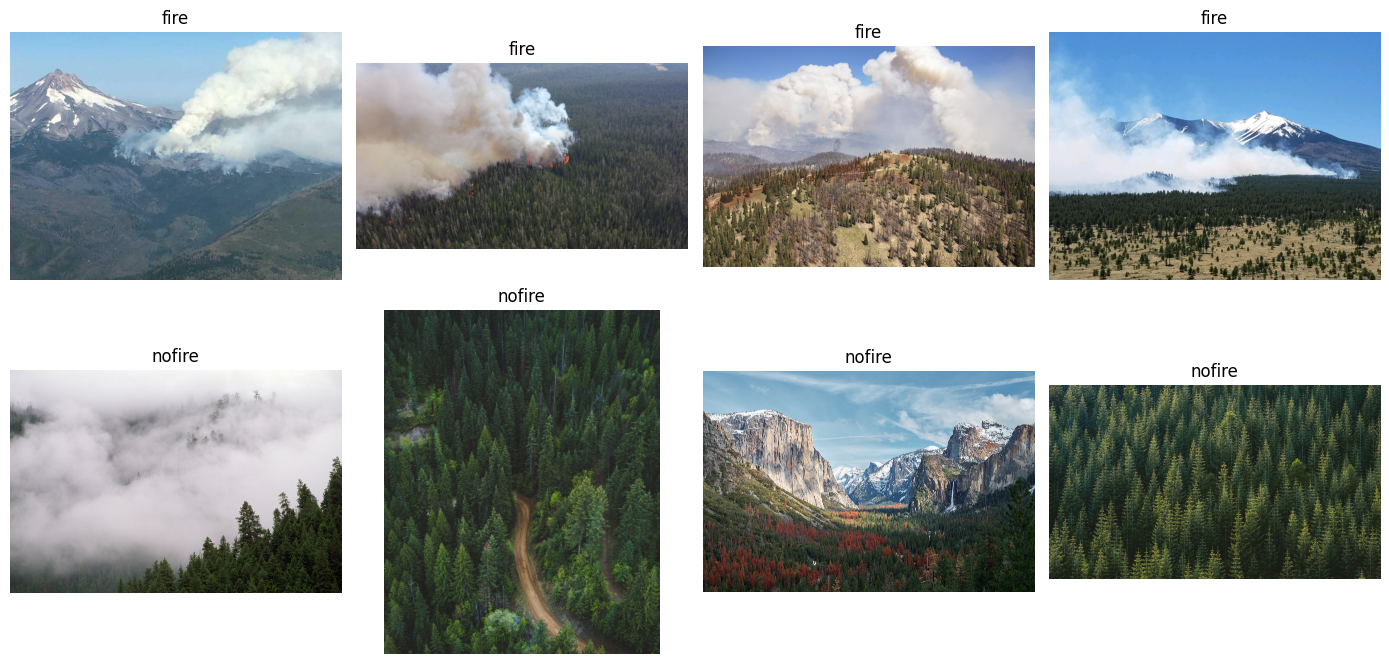

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for row, j in enumerate(classes):
    path = os.path.join(datad, 'train', j)
    files = [f for f in os.listdir(path) if f.lower().endswith(imgext)]
    sample = random.sample(files, 4)
    for col, f in enumerate(sample):
        with Image.open(os.path.join(path, f)) as img:
            img = img.convert('RGB')
            axes[row, col].imshow(img)
            axes[row, col].set_title(j)
            axes[row, col].axis('off')

plt.tight_layout()
plt.show()

Проверим на наличие дубликатов

In [ ]:
import hashlib

def filehash(path):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b''):
            h.update(chunk)
    return h.hexdigest()

hashes = {}
for i in splits:
    hashes[i] = set()
    for j in classes:
        path = os.path.join(datad, i, j)
        files = [f for f in os.listdir(path) if f.lower().endswith(imgext)]
        for f in tqdm(files, desc=i + '/' + j):
            hashes[i].add(filehash(os.path.join(path, f)))

print('Совпадения train и val:', len(hashes['train'] & hashes['val']))
print('Совпадения train и test:', len(hashes['train'] & hashes['test']))
print('Совпадения val и test:', len(hashes['val'] & hashes['test']))

test/nofire: 100%|██████████| 251/251 [00:10<00:00, 24.40it/s]

Совпадения train и val: 0
Совпадения train и test: 0
Совпадения val и test: 0


Полных дубликатов между выборками нет

## Подготовка данных

Приведем изображения к единому размеру и цветовому режиму, сохраним копию

In [ ]:
from PIL import ImageOps

outdir = datad + '_224'
imgsize =(224, 224)
for i in splits:
    for j in classes:
        src = os.path.join(datad,i,j)
        dst = os.path.join(outdir,i,j)
        os.makedirs(dst, exist_ok=True)
        files = [f for f in os.listdir(src) if f.lower().endswith(imgext)]
        for f in tqdm(files, desc=i + '/' + j):
            name = os.path.splitext(f)[0] + '.jpg'
            outpath = os.path.join(dst, name)
            if os.path.exists(outpath):
                continue
            with Image.open(os.path.join(src, f)) as img:
                img = ImageOps.exif_transpose(img)
                img = img.convert('RGB')
                img = img.resize(imgsize, Image.Resampling.LANCZOS)
                img.save(outpath, format='JPEG', quality=90)

print('Подготовленный датасет сохранён:', outdir)

test/nofire: 100%|██████████| 251/251 [02:30<00:00,  1.67it/s]

Подготовленный датасет сохранён: /content/drive/MyDrive/the_wildfire_dataset_2n_version_224


Сделаем проверку

In [ ]:
for i in splits:
    print(i)
    for j in classes:
        path = os.path.join(outdir, i, j)
        files = [f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg'))]
        szs = set()
        mds = set()
        for f in files:
            with Image.open(os.path.join(path, f)) as img:
                szs.add(img.size)
                mds.add(img.mode)
        assert len(files) == counts[i][j]
        assert szs == {imgsize}
        assert mds == {'RGB'}
        print('%s: %d файлов, размер=%s, режим=%s' % (j, len(files), szs, mds))

train
fire: 730 файлов, размер={(224, 224)}, режим={'RGB'}
nofire: 1157 файлов, размер={(224, 224)}, режим={'RGB'}
val
fire: 156 файлов, размер={(224, 224)}, режим={'RGB'}
nofire: 246 файлов, размер={(224, 224)}, режим={'RGB'}
test
fire: 159 файлов, размер={(224, 224)}, режим={'RGB'}
nofire: 251 файлов, размер={(224, 224)}, режим={'RGB'}


Размерность датасета не поменяоась, привели файлы к единому размеру и RGB

Посчитаем среднее и стандартное отклонение для каждого цветового канала по обучающей выборке

In [ ]:
ds = datasets.ImageFolder(os.path.join(outdir, 'train'), transform=transforms.ToTensor())
loader = DataLoader(ds, batch_size=32, shuffle=False, num_workers=2)
psum = torch.zeros(3)
psumsq = torch.zeros(3)
n = 0
for imgs, labels in tqdm(loader):
    b, c, h, w = imgs.shape
    psum += imgs.sum(dim=[0, 2, 3])
    psumsq += (imgs ** 2).sum(dim=[0, 2, 3])
    n += b * h * w
mean = psum/n
std = torch.sqrt(psumsq/n - mean ** 2)
print('Mean:', mean.tolist())
print('Std:', std.tolist())

100%|██████████| 59/59 [00:08<00:00,  6.99it/s]

Mean: [0.4157443046569824, 0.4036860466003418, 0.37576547265052795]
Std: [0.27700716257095337, 0.2600300908088684, 0.28260019421577454]


Эти значения потом используются для нормализации изображений во всех выборках

Загрузим все три выборки, присвоим метки и к каждому изображению применим преобразование в тензор и нормализацию по статистикам обучающей выборки

In [ ]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=mean.tolist(), std=std.tolist())])

trainds = datasets.ImageFolder(os.path.join(outdir,'train'), transform=transform)
valds = datasets.ImageFolder(os.path.join(outdir, 'val'), transform=transform)
testds = datasets.ImageFolder(os.path.join(outdir, 'test'), transform=transform)

print('Классы:', trainds.classes)
print('Индексы классов:', trainds.class_to_idx)
print('Train:', len(trainds))
print('Validation:', len(valds))
print('Test:', len(testds))

Классы: ['fire', 'nofire']
Индексы классов: {'fire': 0, 'nofire': 1}
Train: 1887
Validation: 402
Test: 410


Создадим загрузчики данных, которые будут передавать изображения модели батчами,перед каждой эпохой будет перемешиваться только обучающая выборка

In [ ]:
batchsize = 32
trainloader = DataLoader(trainds, batch_size=batchsize, shuffle=True, num_workers=2)
valloader = DataLoader(valds, batch_size=batchsize, shuffle=False, num_workers=2)
testloader = DataLoader(testds, batch_size=batchsize, shuffle=False, num_workers=2)

print('Количество батчей:')
print('Train:', len(trainloader))
print('Validation:', len(valloader))
print('Test:', len(testloader))

Количество батчей:
Train: 59
Validation: 13
Test: 13


Проверим размер одного батча и формат меток перед переходом к построению нейронной сети

In [ ]:
images, labels = next(iter(trainloader))
print('Размер батча изображений:', images.shape)
print('Размер батча меток:', labels.shape)
print('Тип данных изображений:', images.dtype)
print('Метки первых изображений:', labels[:10])

Размер батча изображений: torch.Size([32, 3, 224, 224])
Размер батча меток: torch.Size([32])
Тип данных изображений: torch.float32
Метки первых изображений: tensor([0, 0, 1, 0, 0, 0, 1, 1, 1, 0])


Данные подготовлены корректно: изображения поступают батчами по 32 объекта в формате размер батча, каналы, высота, ширина, а каждому изображению соответствует бинарная метка класса

# Обучение моделей

## Baseline CNN

В качестве базовой модели построим простую свёрточную нейронную сеть, обучаемую с нуля. Её результаты будут использоваться как отправная точка для сравнения с более сложными архитектурами.


In [ ]:
# Зафиксируем seed для воспроизводимости

def seed_everything(seed):
    random.seed(seed) # фиксируем генератор случайных чисел
    os.environ['PYTHONHASHSEED'] = str(seed) # фиксируем заполнения хешей
    np.random.seed(seed) # фиксируем генератор случайных чисел numpy
    torch.manual_seed(seed) # фиксируем генератор случайных чисел pytorch
    torch.cuda.manual_seed(seed) # фиксируем генератор случайных чисел для GPU
    torch.backends.cudnn.deterministic = True # выбираем только детерминированные алгоритмы (для сверток)
    torch.backends.cudnn.benchmark = False # фиксируем алгоритм вычисления сверток

Соберём основные параметры baseline-эксперимента в одном классе. Это позволит использовать одинаковые настройки при обучении и передавать их в систему логирования:

In [ ]:
class CFG:

    # Параметры логирования эксперимента
    project = 'wildfire_image_classification'
    entity = 'dmshukakidze-hse-university'
    wandb = True

    # Параметры обучения
    num_epochs = 10
    train_batch_size = 32
    val_batch_size = 32
    test_batch_size = 32
    num_workers = 0
    lr = 3e-4
    seed = 42

    # Параметры данных
    image_size = 224
    classes = ('fire', 'nofire')

In [ ]:
# Переведем наш класс с параметрами в словарь

def class2dict(f):
  return dict((name, getattr(f, name)) for name in dir(f) if not name.startswith('__'))

Строим первую базовую сеть:

In [ ]:
class LeNet5(torch.nn.Module):
    def __init__(self,
                 activation='tanh',
                 pooling='avg',
                 conv_size=5
                ):
        super(LeNet5, self).__init__()

        self.conv_size = conv_size

       # установим на выбор функции активации
        if activation == 'tanh':
            activation_function = torch.nn.Tanh()
        elif activation == 'relu':
            activation_function  = torch.nn.ReLU()
        else:
            raise NotImplementedError

        # установим на выбор тип пулинга
        if pooling == 'avg':
            pooling_layer = torch.nn.AvgPool2d(kernel_size=2, stride=2)
        elif pooling == 'max':
            pooling_layer  = torch.nn.MaxPool2d(kernel_size=2, stride=2)
        else:
            raise NotImplementedError


        #первый сверточный блок
        if conv_size == 5:
            self.conv1 = torch.nn.Conv2d(
                in_channels=3, out_channels=6, kernel_size=5, padding=2)
        elif conv_size == 3:
            self.conv1_1 = torch.nn.Conv2d(
                in_channels=3, out_channels=6, kernel_size=3, padding=1)
            self.conv1_2 = torch.nn.Conv2d(
                in_channels=6, out_channels=6, kernel_size=3, padding=1)
        else:
            raise NotImplementedError

        self.act1 = activation_function
        self.pool1 = pooling_layer

        # второй сверточный блок
        if conv_size == 5:
            self.conv2 = torch.nn.Conv2d(
                in_channels=6, out_channels=16, kernel_size=5, padding=0)
        elif conv_size == 3:
            self.conv2_1 = torch.nn.Conv2d(
                in_channels=6, out_channels=16, kernel_size=3, padding=0)
            self.conv2_2 = torch.nn.Conv2d(
                in_channels=16, out_channels=16, kernel_size=3, padding=0)
        else:
            raise NotImplementedError

        self.act2 = activation_function
        self.pool2 = pooling_layer

        # не забываем про полносвязанные слои
        self.fc1 = torch.nn.Linear(54 * 54 * 16, 120)
        self.act3 = activation_function

        self.fc2 = torch.nn.Linear(120, 84)
        self.act4 = activation_function

        self.fc3 = torch.nn.Linear(84, 2)

    # прямой проход
    def forward(self, x):
        if self.conv_size == 5:
            x = self.conv1(x)
        elif self.conv_size == 3:
            x = self.conv1_2(self.conv1_1(x))
        x = self.act1(x)
        x = self.pool1(x)

        if self.conv_size == 5:
            x = self.conv2(x)
        elif self.conv_size == 3:
            x = self.conv2_2(self.conv2_1(x))

        x = self.act2(x)
        x = self.pool2(x)

        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = self.act3(x)

        x = self.fc2(x)
        x = self.act4(x)

        x = self.fc3(x)

        return x

Создадим функцию, которая выполняет одну эпоху обучения: прямой проход, вычисление функции потерь, обратное распространение ошибки и обновление весов модели:

In [ ]:
def train(model, device, train_loader, optimizer, criterion):
    model.train()
    train_loss = 0
    correct = 0

    for data, target in tqdm(train_loader, total=len(train_loader)):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * data.size(0)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()

    # считаем метрики по всей выборке обучающей
    train_loss/= len(train_loader.dataset)
    train_accuracy =correct / len(train_loader.dataset)

    tqdm.write('\nTrain set: Average loss: {:.4f}, Accuracy: {:.2f}%'.format(train_loss, 100 * train_accuracy))

    return train_loss, train_accuracy

Напишем функцию оценки модели по валидационной выборке:

In [ ]:
# функция инференса
def validate(model, device, val_loader, criterion):
    model.eval()

    val_loss = 0
    correct = 0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)

            loss = criterion(output, target)
            val_loss += loss.item() * data.size(0)

            pred = output.argmax(dim=1)
            correct +=pred.eq(target).sum().item()

            y_true.extend(target.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())

    # считаем метрики по всей валидационной выборке
    val_loss /= len(val_loader.dataset)
    val_accuracy = correct / len(val_loader.dataset)

    val_precision_fire = precision_score(y_true, y_pred, pos_label=0, zero_division=0)
    val_recall_fire = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    val_f1_fire = f1_score(y_true, y_pred, pos_label=0, zero_division=0)

    tqdm.write('Validation set: Loss: {:.4f}, Accuracy: {:.2f}%, Precision fire: {:.4f}, Recall fire: {:.4f}, F1 fire: {:.4f}'.format(
        val_loss, 100 * val_accuracy, val_precision_fire, val_recall_fire, val_f1_fire))

    return val_loss, val_accuracy, val_precision_fire, val_recall_fire, val_f1_fire

Объединим создание модели, выбор устройства, настройку оптимизатора и функции потерь, обучение и валидацию в единую функцию.


Вообще, наиболее важная метрика для нас - Recall, так как цена ошибки наиболее велика, если реально пожар есть, а мы его не задетектировали. Но если мы будем ориентироваться только на неё, то мы можем просто тупо на все значения говорить, что пожар есть и детектировать его даже там, где его нет. А метрика F1 - как раз учитывает это. Она учитывает и Recall и Precision. Поэтому будем ориентироваться на неё и фиксировать веса модели по наилучшему показателю этой метрике:

In [ ]:
def run_experiment(model):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    architecture = model.__class__.__name__
    run_name = getattr(model, 'run_name', architecture.lower())
    model_config = getattr(model, 'model_config', {})

    experiment_config = class2dict(CFG)
    experiment_config['architecture'] = architecture
    experiment_config['selection_metric'] = 'val_f1_fire'
    experiment_config.update(model_config)

    if CFG.wandb:
        wandb.init(project=CFG.project, entity=CFG.entity or None, name=run_name, reinit=True, config=experiment_config)
        wandb.watch(model, log='all')

    optimizer = optim.Adam(model.parameters(), lr=CFG.lr)
    criterion = nn.CrossEntropyLoss()

    history = {
        'train_loss': [],
        'train_accuracy': [],
        'val_loss': [],
        'val_accuracy': [],
        'val_precision_fire': [],
        'val_recall_fire': [],
        'val_f1_fire': []
    }

    best_val_loss = 0
    best_val_accuracy = 0
    best_val_precision_fire = 0
    best_val_recall_fire = 0
    best_val_f1_fire = -1
    best_epoch = 0
    best_model_state = None

    for epoch in range(1, CFG.num_epochs + 1):
        print(f'\nEpoch: {epoch}')

        train_loss, train_accuracy = train(model, device, train_loader, optimizer, criterion)

        val_loss, val_accuracy, val_precision_fire, val_recall_fire, val_f1_fire = validate(model, device, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_accuracy)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_accuracy)
        history['val_precision_fire'].append(val_precision_fire)
        history['val_recall_fire'].append(val_recall_fire)
        history['val_f1_fire'].append(val_f1_fire)

        if CFG.wandb:
            wandb.log({
                'epoch': epoch,
                'train_loss': train_loss,
                'train_accuracy': train_accuracy,
                'val_loss': val_loss,
                'val_accuracy': val_accuracy,
                'val_precision_fire': val_precision_fire,
                'val_recall_fire': val_recall_fire,
                'val_f1_fire': val_f1_fire})

        # сохраняем веса с максимальным F1 по классу fire:
        if val_f1_fire > best_val_f1_fire:
            best_val_loss = val_loss
            best_val_accuracy = val_accuracy
            best_val_precision_fire = val_precision_fire
            best_val_recall_fire = val_recall_fire
            best_val_f1_fire = val_f1_fire
            best_epoch = epoch

            best_model_state = {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}

    model.load_state_dict(best_model_state)
    model = model.to(device)

    model_path = f'/content/{run_name}_best.pth'

    torch.save({
        'model_state_dict': best_model_state,
        'best_epoch': best_epoch,
        'best_val_loss': best_val_loss,
        'best_val_accuracy': best_val_accuracy,
        'best_val_precision_fire': best_val_precision_fire,
        'best_val_recall_fire': best_val_recall_fire,
        'best_val_f1_fire': best_val_f1_fire,
        'config': experiment_config
    }, model_path)

    if CFG.wandb:
        wandb.run.summary['best_epoch'] = best_epoch
        wandb.run.summary['best_val_loss'] = best_val_loss
        wandb.run.summary['best_val_accuracy'] = best_val_accuracy
        wandb.run.summary['best_val_precision_fire'] = best_val_precision_fire
        wandb.run.summary['best_val_recall_fire'] = best_val_recall_fire
        wandb.run.summary['best_val_f1_fire'] = best_val_f1_fire

        #сохраняем обученную модель:
        model_artifact = wandb.Artifact(name=f'{run_name}_model', type='model')
        model_artifact.add_file(model_path)
        wandb.log_artifact(model_artifact)

        wandb.finish()


    print(
        '\nTraining is ended!',
        '\nBest epoch by F1 fire:', best_epoch,
        '\nValidation loss:', round(best_val_loss, 4),
        '\nAccuracy:', round(best_val_accuracy * 100, 2), '%',
        '\nPrecision fire:', round(best_val_precision_fire, 4),
        '\nRecall fire:', round(best_val_recall_fire, 4),
        '\nF1 fire:', round(best_val_f1_fire, 4)
      )

    return model, history

функцию активации будем использовать tanh, средний пулинг и свёрточные ядра размером 5 на 5, как в классическом варианте архитектуры

In [ ]:
seed_everything(CFG.seed)

baseline_model = LeNet5(activation= 'tanh', pooling='avg', conv_size = 5)

In [ ]:
summary(model=baseline_model,
        input_size=(CFG.train_batch_size, 3, CFG.image_size, CFG.image_size),  # входной батч
        col_names=['input_size', 'output_size', 'num_params', 'trainable'], # что хотим посмотреть
        col_width=20
)

Layer (type:depth-idx)                   Input Shape          Output Shape         Param #              Trainable
LeNet5                                   [32, 3, 224, 224]    [32, 2]              --                   True
├─Conv2d: 1-1                            [32, 3, 224, 224]    [32, 6, 224, 224]    456                  True
├─Tanh: 1-2                              [32, 6, 224, 224]    [32, 6, 224, 224]    --                   --
├─AvgPool2d: 1-3                         [32, 6, 224, 224]    [32, 6, 112, 112]    --                   --
├─Conv2d: 1-4                            [32, 6, 112, 112]    [32, 16, 108, 108]   2,416                True
├─Tanh: 1-5                              [32, 16, 108, 108]   [32, 16, 108, 108]   --                   --
├─AvgPool2d: 1-6                         [32, 16, 108, 108]   [32, 16, 54, 54]     --                   --
├─Linear: 1-7                            [32, 46656]          [32, 120]            5,598,840            True
├─Tanh: 1-8           

Подключимся к wandb для сохранения параметров эксперимента, метрик обучения и результатов модели:

In [ ]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: dmshukakidze (dmshukakidze-hse-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
baseline_model, baseline_history = run_experiment(baseline_model)


Epoch: 1


100%|██████████| 59/59 [00:10<00:00,  5.82it/s]



Train set: Average loss: 0.6552, Accuracy: 66.35%
Validation set: Loss: 0.5693, Accuracy: 72.64%, Precision fire: 0.7738, Recall fire: 0.4167, F1 fire: 0.5417

Epoch: 2


100%|██████████| 59/59 [00:09<00:00,  6.06it/s]



Train set: Average loss: 0.5456, Accuracy: 72.23%
Validation set: Loss: 0.5058, Accuracy: 73.38%, Precision fire: 0.6763, Recall fire: 0.6026, F1 fire: 0.6373

Epoch: 3


...


Train set: Average loss: 0.1467, Accuracy: 95.76%
Validation set: Loss: 0.5376, Accuracy: 76.37%, Precision fire: 0.6826, Recall fire: 0.7308, F1 fire: 0.7059

Epoch: 10


100%|██████████| 59/59 [00:10<00:00,  5.86it/s]



Train set: Average loss: 0.1043, Accuracy: 96.93%
Validation set: Loss: 0.5738, Accuracy: 75.62%, Precision fire: 0.6686, Recall fire: 0.7372, F1 fire: 0.7012


epoch,▁▂▃▃▄▅▆▆▇█
train_accuracy,▁▂▃▄▅▅▆▇██
train_loss,█▇▆▅▅▄▃▂▂▁
val_accuracy,▁▂▂▃█▇▆▄▅▄
val_f1_fire,▁▅▄▆██▇▆▇▇
val_loss,█▄▃▃▁▂▂▄▆█
val_precision_fire,█▂▅▂▇▇▃▃▂▁
val_recall_fire,▁▅▃▆▇▇█▆██
best_epoch,5
best_val_accuracy,0.79602
best_val_f1_fire,0.72667



Training is ended! 
Best epoch by F1 fire: 5 
Validation loss: 0.4463 
Accuracy: 79.6 % 
Precision fire: 0.7569 
Recall fire: 0.6987 
F1 fire: 0.7267


Посмотрим на метрики, которые мы получили:

In [ ]:
baseline_logs = pd.DataFrame(baseline_history)
baseline_logs.insert(0, 'epoch', range(1, len(baseline_logs) + 1))
baseline_logs

,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_precision_fire,val_recall_fire,val_f1_fire
0,1,0.655188,0.663487,0.569289,0.726368,0.773810,0.416667,0.541667
1,2,0.545597,0.722311,0.505818,0.733831,0.676259,0.602564,0.637288
2,3,0.491525,0.759936,0.482124,0.738806,0.725664,0.525641,0.609665
3,4,0.448285,0.788553,0.482265,0.751244,0.684211,0.666667,0.675325
4,5,0.408488,0.819290,0.446280,0.796020,0.756944,0.698718,0.726667
5,6,0.330514,0.855856,0.457500,0.791045,0.760870,0.673077,0.714286
6,7,0.270556,0.898251,0.469046,0.773632,0.701863,0.724359,0.712934
7,8,0.203252,0.926868,0.509119,0.758706,0.700680,0.660256,0.679868
8,9,0.146660,0.957605,0.537630,0.763682,0.682635,0.730769,0.705882
9,10,0.104301,0.969263,0.573826,0.756219,0.668605,0.737179,0.701220


Выведем лучшую эпоху:

In [ ]:
best_baseline = baseline_logs.loc[baseline_logs['val_f1_fire'].idxmax()]
best_baseline

,4
epoch,5.000000
train_loss,0.408488
train_accuracy,0.819290
val_loss,0.446280
val_accuracy,0.796020
val_precision_fire,0.756944
val_recall_fire,0.698718
val_f1_fire,0.726667


### Вывод по baseline моделе

Лучший результат по F1 score модель показала на 5 эпохе:

Accuracy - 79,60%

Precision для класса fire — 0,7569

Recall для класса fire — 0,6987

F1-score для класса fire — 0,7267

После 5-й эпохи качество на обучающей выборке продолжает расти, но качество на валидационной выборке не улучшается. Это говорит о начале переобучения.

Baseline модель показала приемлемый результат, но надо улучшать дальше, поэтому переходим к моделе 2

## Вторая модель, более глубокая CNN

### V1

Попробуем увеличить количество свёрточных блоков и каналов, заменим tanh на relu, а средний пулинг — на максимальный. Для стабилизации обучения добавим батч нормализацию, а для снижения переобучения дропаут.

Вообще, было бы хорошо применить аугментацию, чтобы увеличить наш датасает, но пока её не применяем, чтобы отдельно оценить влияние изменения архитектуры

In [ ]:
class improvedcnn(nn.Module):
    def __init__(self, dropout=0.3):
        super(improvedcnn, self).__init__()

        # Название и параметры эксперимента для W&B
        self.run_name = 'improvedcnn'

        self.model_config = {
            'channels': [32, 64, 128],
            'activation': 'relu',
            'pooling': 'maxpool2d',
            'batch_norm': True,
            'dropout': dropout,
            'adaptive_pooling': [7, 7],
            'hidden_size': 256,
            'conv_blocks': 3,
            'conv_per_block': 1
        }

        # 1 свёрточный блок
        self.conv1= nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 =  nn.MaxPool2d(kernel_size=2, stride=2)

        # 2 свёрточный блок
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # 3 свёрточный блок
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3= nn.MaxPool2d(kernel_size=2, stride=2)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((7, 7))

        # полносвязные слои тоже не забываем
        self.fc1 = nn.Linear(128 * 7 * 7, 256)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(256, 2)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))

        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [ ]:
seed_everything(CFG.seed)

improved_model = improvedcnn()

summary(
    improved_model,
    input_size=(CFG.train_batch_size, 3, CFG.image_size, CFG.image_size),
    col_names=['input_size', 'output_size', 'num_params', 'trainable'],
    col_width=20
)

Layer (type:depth-idx)                   Input Shape          Output Shape         Param #              Trainable
improvedcnn                              [32, 3, 224, 224]    [32, 2]              --                   True
├─Conv2d: 1-1                            [32, 3, 224, 224]    [32, 32, 224, 224]   896                  True
├─BatchNorm2d: 1-2                       [32, 32, 224, 224]   [32, 32, 224, 224]   64                   True
├─MaxPool2d: 1-3                         [32, 32, 224, 224]   [32, 32, 112, 112]   --                   --
├─Conv2d: 1-4                            [32, 32, 112, 112]   [32, 64, 112, 112]   18,496               True
├─BatchNorm2d: 1-5                       [32, 64, 112, 112]   [32, 64, 112, 112]   128                  True
├─MaxPool2d: 1-6                         [32, 64, 112, 112]   [32, 64, 56, 56]     --                   --
├─Conv2d: 1-7                            [32, 64, 56, 56]     [32, 128, 56, 56]    73,856               True
├─BatchNorm2d: 1-8

In [ ]:
improved_model_v1, improved_history_v1 = run_experiment(improved_model)


Epoch: 1


100%|██████████| 59/59 [00:12<00:00,  4.61it/s]



Train set: Average loss: 0.5576, Accuracy: 73.45%
Validation set: Loss: 0.4598, Accuracy: 76.87%, Precision fire: 0.6760, Recall fire: 0.7756, F1 fire: 0.7224

Epoch: 2


100%|██████████| 59/59 [00:12<00:00,  4.55it/s]



Train set: Average loss: 0.4503, Accuracy: 78.54%
Validation set: Loss: 0.4205, Accuracy: 80.10%, Precision fire: 0.7043, Recall fire: 0.8397, F1 fire: 0.7661

Epoch: 3


...


Train set: Average loss: 0.2997, Accuracy: 86.86%
Validation set: Loss: 0.3725, Accuracy: 84.83%, Precision fire: 0.8188, Recall fire: 0.7821, F1 fire: 0.8000

Epoch: 10


100%|██████████| 59/59 [00:12<00:00,  4.54it/s]



Train set: Average loss: 0.2966, Accuracy: 86.65%
Validation set: Loss: 0.3595, Accuracy: 84.33%, Precision fire: 0.8550, Recall fire: 0.7179, F1 fire: 0.7805


epoch,▁▂▃▃▄▅▆▆▇█
train_accuracy,▁▄▅▆▆▇▇▇██
train_loss,█▅▄▃▃▂▂▂▁▁
val_accuracy,▁▄▃▃▅▇▆▅██
val_f1_fire,▃▆▃▁▄▇▇▇█▇
val_loss,█▅▅▆▃▃▃▄▂▁
val_precision_fire,▁▂▅█▇▇▄▃▇█
val_recall_fire,▆█▃▁▃▅██▇▅
best_epoch,9
best_val_accuracy,0.84826
best_val_f1_fire,0.8



Training is ended! 
Best epoch by F1 fire: 9 
Validation loss: 0.3725 
Accuracy: 84.83 % 
Precision fire: 0.8188 
Recall fire: 0.7821 
F1 fire: 0.8


Посмотрим на лучший результат:

In [ ]:
logs_v1 = pd.DataFrame(improved_history_v1)
logs_v1.insert(0, 'epoch', range(1, len(logs_v1) + 1))

best_v1 = logs_v1.loc[logs_v1['val_f1_fire'].idxmax()]
best_v1

,8
epoch,9.000000
train_loss,0.299705
train_accuracy,0.868574
val_loss,0.372463
val_accuracy,0.848259
val_precision_fire,0.818792
val_recall_fire,0.782051
val_f1_fire,0.800000


**Вывод**
Лучший результат модель показала на 9 эпохе:

Accuracy - 84,83%

Precision для класса fire - 0,8188

Recall для класса fire - 0,7821

F1 - 0,8

Видим по всем метрикам заметное улучшение

При этом разница между Accuracy на обучающей и валидационной выборке небольшая- 86,86% и 84,83%. Сильного переобучения не наблюдается, поэтому можно проверить, даст ли увеличение мощности модели дополнительное улучшение - количество каналов увеличим с 32 64 128 до 64 128 256, а размер скрытого полносвязного слоя - с 256 до 512 нейронов:

### V2

In [ ]:
class improvedcnn_v2(nn.Module):
    def __init__(self, dropout=0.3):
        super(improvedcnn_v2, self).__init__()

        # Название и параметры эксперимента для W&B
        self.run_name = 'improvedcnn_v2'

        self.model_config = {
            'channels': [64, 128, 256],
            'activation': 'relu',
            'pooling': 'maxpool2d',
            'batch_norm': True,
            'dropout': dropout,
            'adaptive_pooling': [7, 7],
            'hidden_size': 512,
            'conv_blocks': 3,
            'conv_per_block': 1
        }

        # 1 свёрточный блок
        self.conv1= nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.pool1 =  nn.MaxPool2d(kernel_size=2, stride=2)

        # 2 свёрточный блок
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # 3 свёрточный блок
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.pool3= nn.MaxPool2d(kernel_size=2, stride=2)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((7, 7))

        # полносвязные слои тоже не забываем
        self.fc1 = nn.Linear(256 * 7 * 7, 512)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(512, 2)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))

        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [ ]:
seed_everything(CFG.seed)

improved_model = improvedcnn_v2()

summary(
    improved_model,
    input_size=(CFG.train_batch_size, 3, CFG.image_size, CFG.image_size),
    col_names=['input_size', 'output_size', 'num_params', 'trainable'],
    col_width=20
)

Layer (type:depth-idx)                   Input Shape          Output Shape         Param #              Trainable
improvedcnn_v2                           [32, 3, 224, 224]    [32, 2]              --                   True
├─Conv2d: 1-1                            [32, 3, 224, 224]    [32, 64, 224, 224]   1,792                True
├─BatchNorm2d: 1-2                       [32, 64, 224, 224]   [32, 64, 224, 224]   128                  True
├─MaxPool2d: 1-3                         [32, 64, 224, 224]   [32, 64, 112, 112]   --                   --
├─Conv2d: 1-4                            [32, 64, 112, 112]   [32, 128, 112, 112]  73,856               True
├─BatchNorm2d: 1-5                       [32, 128, 112, 112]  [32, 128, 112, 112]  256                  True
├─MaxPool2d: 1-6                         [32, 128, 112, 112]  [32, 128, 56, 56]    --                   --
├─Conv2d: 1-7                            [32, 128, 56, 56]    [32, 256, 56, 56]    295,168              True
├─BatchNorm2d: 1-8

In [ ]:
improved_model_v2, improved_history_v2 = run_experiment(improved_model)


Epoch: 1


100%|██████████| 59/59 [00:17<00:00,  3.33it/s]



Train set: Average loss: 0.7206, Accuracy: 70.48%
Validation set: Loss: 0.4617, Accuracy: 77.11%, Precision fire: 0.7051, Recall fire: 0.7051, F1 fire: 0.7051

Epoch: 2


100%|██████████| 59/59 [00:17<00:00,  3.38it/s]



Train set: Average loss: 0.4442, Accuracy: 79.70%
Validation set: Loss: 0.4416, Accuracy: 77.61%, Precision fire: 0.8367, Recall fire: 0.5256, F1 fire: 0.6457

Epoch: 3


...


Train set: Average loss: 0.3105, Accuracy: 86.22%
Validation set: Loss: 0.4458, Accuracy: 79.10%, Precision fire: 0.8750, Recall fire: 0.5385, F1 fire: 0.6667

Epoch: 10


100%|██████████| 59/59 [00:17<00:00,  3.40it/s]



Train set: Average loss: 0.2951, Accuracy: 87.49%
Validation set: Loss: 0.3910, Accuracy: 82.34%, Precision fire: 0.7742, Recall fire: 0.7692, F1 fire: 0.7717


epoch,▁▂▃▃▄▅▆▆▇█
train_accuracy,▁▅▅▆▆▇▇▇▇█
train_loss,█▃▃▂▂▂▂▂▁▁
val_accuracy,▁▂▅▄▆█▇▆▄█
val_f1_fire,▄▁▆▄▅▆▆█▂▇
val_loss,█▆▄▅▃▃▁▅▇▂
val_precision_fire,▁▆▂▅▆▆▅▁█▄
val_recall_fire,▅▁▆▃▃▄▄█▁▆
best_epoch,8
best_val_accuracy,0.80846
best_val_f1_fire,0.78187



Training is ended! 
Best epoch by F1 fire: 8 
Validation loss: 0.4298 
Accuracy: 80.85 % 
Precision fire: 0.7005 
Recall fire: 0.8846 
F1 fire: 0.7819


In [ ]:
logs_v2 = pd.DataFrame(improved_history_v2)
logs_v2.insert(0, 'epoch', range(1, len(logs_v2) + 1))

best_v2 = logs_v2.loc[logs_v2['val_f1_fire'].idxmax()]
best_v2

,7
epoch,8.000000
train_loss,0.337644
train_accuracy,0.855326
val_loss,0.429837
val_accuracy,0.808458
val_precision_fire,0.700508
val_recall_fire,0.884615
val_f1_fire,0.781870


**Вывод**

Количество параметров выросло примерно с 1,7 миллионов до 6,8 милионов

Лучший результат был получен на 8 эпохе:

Accuracy — 80,85%

Precision для класса fire — 0,7005

Recall для класса fire — 0,8846

F1-score для класса fire — 0,7819

Модель стала обнаруживать больше реальных пожаров, поэтому recall вырос. Однако precision и общая accuracy снизились. Модель стала чаще ошибочно относить изображения без пожара к классу fire

По сравнению с первой вариацией F1 уменьшился с 0,8 до 0,7819

Поэтому получаем, что простое увеличение количества фильтров и параметров не привело к улучшению общего качества

Далее попробуем изменить не только ширину, но и глубину модели: добавим ещё один свёрточный блок и будем использовать по две последовательные свёртки внутри каждого блока:

### V3

In [ ]:
class improvedcnn_v3(nn.Module):
    def __init__(self, dropout=0.3):
        super(improvedcnn_v3, self).__init__()

        # Название и параметры эксперимента для W&B
        self.run_name = 'improvedcnn_v3'

        self.model_config = {
            'channels': [64, 128, 256, 512],
            'activation': 'relu',
            'pooling': 'maxpool2d',
            'batch_norm': True,
            'dropout': dropout,
            'adaptive_pooling': [4, 4],
            'hidden_size': 512,
            'conv_blocks': 4,
            'conv_per_block': 2
        }

        # 1 свёрточный блок
        self.conv1_1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1_1 = nn.BatchNorm2d(64)
        self.conv1_2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn1_2 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # 2 свёрточный блок
        self.conv2_1 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2_1 = nn.BatchNorm2d(128)
        self.conv2_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn2_2 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # 3 свёрточный блок
        self.conv3_1 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3_1 = nn.BatchNorm2d(256)
        self.conv3_2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn3_2 = nn.BatchNorm2d(256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # 4 свёрточный блок
        self.conv4_1 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn4_1 = nn.BatchNorm2d(512)
        self.conv4_2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.bn4_2 = nn.BatchNorm2d(512)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((2, 2))

        # полносвязные слои тоже не забываем
        self.fc1 = nn.Linear(512 * 2 * 2, 512)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(512, 2)

    def forward(self, x):
        x = F.relu(self.bn1_1(self.conv1_1(x)))
        x = F.relu(self.bn1_2(self.conv1_2(x)))
        x = self.pool1(x)

        x = F.relu(self.bn2_1(self.conv2_1(x)))
        x = F.relu(self.bn2_2(self.conv2_2(x)))
        x = self.pool2(x)

        x = F.relu(self.bn3_1(self.conv3_1(x)))
        x = F.relu(self.bn3_2(self.conv3_2(x)))
        x = self.pool3(x)

        x = F.relu(self.bn4_1(self.conv4_1(x)))
        x = F.relu(self.bn4_2(self.conv4_2(x)))
        x = self.pool4(x)

        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [ ]:
seed_everything(CFG.seed)

improved_model = improvedcnn_v3()

summary(
    improved_model,
    input_size=(CFG.train_batch_size, 3, CFG.image_size, CFG.image_size),
    col_names=['input_size', 'output_size', 'num_params', 'trainable'],
    col_width=20
)

Layer (type:depth-idx)                   Input Shape          Output Shape         Param #              Trainable
improvedcnn_v3                           [32, 3, 224, 224]    [32, 2]              --                   True
├─Conv2d: 1-1                            [32, 3, 224, 224]    [32, 64, 224, 224]   1,792                True
├─BatchNorm2d: 1-2                       [32, 64, 224, 224]   [32, 64, 224, 224]   128                  True
├─Conv2d: 1-3                            [32, 64, 224, 224]   [32, 64, 224, 224]   36,928               True
├─BatchNorm2d: 1-4                       [32, 64, 224, 224]   [32, 64, 224, 224]   128                  True
├─MaxPool2d: 1-5                         [32, 64, 224, 224]   [32, 64, 112, 112]   --                   --
├─Conv2d: 1-6                            [32, 64, 112, 112]   [32, 128, 112, 112]  73,856               True
├─BatchNorm2d: 1-7                       [32, 128, 112, 112]  [32, 128, 112, 112]  256                  True
├─Conv2d: 1-8   

In [ ]:
improved_model_v3, improved_history_v3 = run_experiment(improved_model)


Epoch: 1


100%|██████████| 59/59 [00:33<00:00,  1.75it/s]



Train set: Average loss: 0.5164, Accuracy: 74.83%
Validation set: Loss: 0.5252, Accuracy: 75.62%, Precision fire: 0.8295, Recall fire: 0.4679, F1 fire: 0.5984

Epoch: 2


100%|██████████| 59/59 [00:33<00:00,  1.76it/s]



Train set: Average loss: 0.4458, Accuracy: 79.54%
Validation set: Loss: 0.4700, Accuracy: 76.87%, Precision fire: 0.7520, Recall fire: 0.6026, F1 fire: 0.6690

Epoch: 3


...


Train set: Average loss: 0.3607, Accuracy: 84.10%
Validation set: Loss: 0.4297, Accuracy: 81.09%, Precision fire: 0.7299, Recall fire: 0.8141, F1 fire: 0.7697

Epoch: 10


100%|██████████| 59/59 [00:35<00:00,  1.65it/s]



Train set: Average loss: 0.3525, Accuracy: 83.68%
Validation set: Loss: 0.4618, Accuracy: 79.10%, Precision fire: 0.7466, Recall fire: 0.6987, F1 fire: 0.7219


epoch,▁▂▃▃▄▅▆▆▇█
train_accuracy,▁▅▄▇▆▇█▇██
train_loss,█▅▄▃▃▂▂▂▁▁
val_accuracy,▁▃▃▄▆▅▅▇█▅
val_f1_fire,▁▄▄▆▇▆▆▆█▆
val_loss,█▄▃▃▃▃▄▂▁▃
val_precision_fire,█▃▃▂▁▄▂▆▂▃
val_recall_fire,▁▄▄▆▇▅▆▅█▆
best_epoch,9
best_val_accuracy,0.81095
best_val_f1_fire,0.7697



Training is ended! 
Best epoch by F1 fire: 9 
Validation loss: 0.4297 
Accuracy: 81.09 % 
Precision fire: 0.7299 
Recall fire: 0.8141 
F1 fire: 0.7697


**Вывод**

Добавление четвёртого свёрточного блока и второй свёртки внутри каждого блока не улучшило качество при прежних параметрах обучения.

Лучший F1 score составил 0,7697,

accuracy 81,09%

Accuracy на обучающей выборке составил только 84,10%, поэтому сильного переобучения не наблюдается. Скорее всего, более глубокая модель не успевает стабильно обучиться за 10 эпох с прежним значением lr.

Поэтому архитектуру оставим без изменений, но увеличим количество эпох, уменьшим lr и добавим постепенное его снижение в процессе обучения


### V4

Увеличиваем количество эпох с 10 до 25, так как более глубокая модель не успела полностью обучиться за 10 эпох

Уменьшаем lr с 3e-4 до 1e-4, чтобы обновление весов происходило более плавно и стабильно - с помощью reducelronplateau, который будет уменьшать lr в 2 раза, если F1 score поклассу fire не улучшается в течение трёх эпох

Заменяем оптимизатор adam на adamW и добавляем weight decay=1e-4, чтобы снизить переобучение

Архитектуру оставляем без изменений

Перезапишем класс и функцию:

In [ ]:
class CFG:

    # Параметры логирования эксперимента
    project = 'wildfire_image_classification'
    entity = 'dmshukakidze-hse-university'
    wandb = True

    # Параметры обучения
    num_epochs = 25
    train_batch_size = 32
    val_batch_size = 32
    test_batch_size = 32
    num_workers = 0
    lr = 1e-4
    weight_decay = 1e-4
    scheduler_factor = 0.5
    scheduler_patience = 3
    min_lr = 1e-6
    seed = 42

    # Параметры данных
    image_size = 224
    classes = ('fire', 'nofire')

In [ ]:
def run_experiment(model):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    architecture = model.__class__.__name__
    run_name = getattr(model, 'run_name', architecture.lower())
    model_config = getattr(model, 'model_config', {})

    experiment_config = class2dict(CFG)
    experiment_config['architecture'] = architecture
    experiment_config['selection_metric'] = 'val_f1_fire'
    experiment_config.update(model_config)

    if CFG.wandb:
        wandb.init(project=CFG.project, entity=CFG.entity or None, name=run_name, reinit=True, config=experiment_config)
        wandb.watch(model, log='all')

    optimizer = optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)

    # Постепенно уменьшаем learning rate
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=CFG.scheduler_factor, patience=CFG.scheduler_patience, min_lr=CFG.min_lr)

    criterion = nn.CrossEntropyLoss()

    history = {
        'train_loss': [],
        'train_accuracy': [],
        'val_loss': [],
        'val_accuracy': [],
        'val_precision_fire': [],
        'val_recall_fire': [],
        'val_f1_fire': [],
        'learning_rate': []
    }

    best_val_loss = 0
    best_val_accuracy = 0
    best_val_precision_fire = 0
    best_val_recall_fire = 0
    best_val_f1_fire = -1
    best_epoch = 0
    best_model_state = None

    for epoch in range(1, CFG.num_epochs + 1):
        print(f'\nEpoch: {epoch}')

        current_lr = optimizer.param_groups[0]['lr']

        train_loss, train_accuracy = train(model, device, train_loader, optimizer, criterion)

        val_loss, val_accuracy, val_precision_fire, val_recall_fire, val_f1_fire = validate(model, device, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_accuracy)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_accuracy)
        history['val_precision_fire'].append(val_precision_fire)
        history['val_recall_fire'].append(val_recall_fire)
        history['val_f1_fire'].append(val_f1_fire)
        history['learning_rate'].append(current_lr)

        if CFG.wandb:
            wandb.log({
                'epoch': epoch,
                'train_loss': train_loss,
                'train_accuracy': train_accuracy,
                'val_loss': val_loss,
                'val_accuracy': val_accuracy,
                'val_precision_fire': val_precision_fire,
                'val_recall_fire': val_recall_fire,
                'val_f1_fire': val_f1_fire,
                'learning_rate': current_lr})

        # сохраняем веса с максимальным F1 по классу fire:
        if val_f1_fire > best_val_f1_fire:
            best_val_loss = val_loss
            best_val_accuracy = val_accuracy
            best_val_precision_fire = val_precision_fire
            best_val_recall_fire = val_recall_fire
            best_val_f1_fire = val_f1_fire
            best_epoch = epoch

            best_model_state = {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}

        scheduler.step(val_f1_fire)

    model.load_state_dict(best_model_state)
    model = model.to(device)

    model_path = f'/content/{run_name}_best.pth'

    torch.save({
        'model_state_dict': best_model_state,
        'best_epoch': best_epoch,
        'best_val_loss': best_val_loss,
        'best_val_accuracy': best_val_accuracy,
        'best_val_precision_fire': best_val_precision_fire,
        'best_val_recall_fire': best_val_recall_fire,
        'best_val_f1_fire': best_val_f1_fire,
        'config': experiment_config
    }, model_path)

    if CFG.wandb:
        wandb.run.summary['best_epoch'] = best_epoch
        wandb.run.summary['best_val_loss'] = best_val_loss
        wandb.run.summary['best_val_accuracy'] = best_val_accuracy
        wandb.run.summary['best_val_precision_fire'] = best_val_precision_fire
        wandb.run.summary['best_val_recall_fire'] = best_val_recall_fire
        wandb.run.summary['best_val_f1_fire'] = best_val_f1_fire

        #сохраняем обученную модель:
        model_artifact = wandb.Artifact(name=f'{run_name}_model', type='model')
        model_artifact.add_file(model_path)
        wandb.log_artifact(model_artifact)

        wandb.finish()


    print(
        '\nTraining is ended!',
        '\nBest epoch by F1 fire:', best_epoch,
        '\nValidation loss:', round(best_val_loss, 4),
        '\nAccuracy:', round(best_val_accuracy * 100, 2), '%',
        '\nPrecision fire:', round(best_val_precision_fire, 4),
        '\nRecall fire:', round(best_val_recall_fire, 4),
        '\nF1 fire:', round(best_val_f1_fire, 4)
      )

    return model, history

In [ ]:
seed_everything(CFG.seed)

improved_model = improvedcnn_v3()

summary(
    improved_model,
    input_size=(CFG.train_batch_size, 3, CFG.image_size, CFG.image_size),
    col_names=['input_size', 'output_size', 'num_params', 'trainable'],
    col_width=20
)

Layer (type:depth-idx)                   Input Shape          Output Shape         Param #              Trainable
improvedcnn_v3                           [32, 3, 224, 224]    [32, 2]              --                   True
├─Conv2d: 1-1                            [32, 3, 224, 224]    [32, 64, 224, 224]   1,792                True
├─BatchNorm2d: 1-2                       [32, 64, 224, 224]   [32, 64, 224, 224]   128                  True
├─Conv2d: 1-3                            [32, 64, 224, 224]   [32, 64, 224, 224]   36,928               True
├─BatchNorm2d: 1-4                       [32, 64, 224, 224]   [32, 64, 224, 224]   128                  True
├─MaxPool2d: 1-5                         [32, 64, 224, 224]   [32, 64, 112, 112]   --                   --
├─Conv2d: 1-6                            [32, 64, 112, 112]   [32, 128, 112, 112]  73,856               True
├─BatchNorm2d: 1-7                       [32, 128, 112, 112]  [32, 128, 112, 112]  256                  True
├─Conv2d: 1-8   

In [ ]:
improved_model_v4, improved_history_v4 = run_experiment(improved_model)


Epoch: 1


100%|██████████| 59/59 [00:27<00:00,  2.16it/s]



Train set: Average loss: 0.4683, Accuracy: 77.37%
Validation set: Loss: 0.4858, Accuracy: 77.11%, Precision fire: 0.6951, Recall fire: 0.7308, F1 fire: 0.7125

Epoch: 2


100%|██████████| 59/59 [00:29<00:00,  2.03it/s]



Train set: Average loss: 0.4102, Accuracy: 81.51%
Validation set: Loss: 0.4557, Accuracy: 77.86%, Precision fire: 0.7081, Recall fire: 0.7308, F1 fire: 0.7192

Epoch: 3


...


Train set: Average loss: 0.0973, Accuracy: 96.45%
Validation set: Loss: 0.3973, Accuracy: 85.07%, Precision fire: 0.8429, Recall fire: 0.7564, F1 fire: 0.7973

Epoch: 25


100%|██████████| 59/59 [00:28<00:00,  2.07it/s]



Train set: Average loss: 0.1001, Accuracy: 95.97%
Validation set: Loss: 0.4591, Accuracy: 81.34%, Precision fire: 0.7288, Recall fire: 0.8269, F1 fire: 0.7748


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
learning_rate,███████████████▃▃▃▃▁▁▁▁▁▁
train_accuracy,▁▃▃▄▄▄▄▄▄▄▅▅▅▅▆▆▆▇▆▇█████
train_loss,█▇▇▆▆▆▅▅▅▅▅▅▄▄▄▃▃▃▃▂▁▁▁▁▁
val_accuracy,▁▂▃▄▃▆▄▆▆▆▇▅▅▅▃▅▇▆▆▆█▇█▇▄
val_f1_fire,▂▂▁▄▅▅▃▅▆▆▇▄▆▆▁▆▇▆▇▆█▇█▆▅
val_loss,█▇▅▅▅▄▄▃▂▃▂▃▄▄█▅▁▄▆▂▃▄▃▄▇
val_precision_fire,▁▂▅▃▁▅▅█▅▄▄▆▃▄▇▃▇▅▃▆▅▆▆▇▂
val_recall_fire,▄▄▁▅▇▅▃▃▅▆█▃█▆▁▇▅▅█▅▇▆▇▅▇
best_epoch,21
best_val_accuracy,0.86318



Training is ended! 
Best epoch by F1 fire: 21 
Validation loss: 0.3838 
Accuracy: 86.32 % 
Precision fire: 0.8024 
Recall fire: 0.859 
F1 fire: 0.8297


**Вывод**

Замена оптимизатора adam на adamW и использование адаптивного планировщика улучшили качество третьей вариации модели.

Лучший результат был получен на 21-й эпохе:

Accuracy — 86,32%

Precision — 0,8024

Recall — 0,8590

F1 score — 0,8297

По сравнению с предыдущей версией F1 score увеличился с 0,7697 до 0,8297. Особенно важным является рост Recall - модель обнаруживает около 85,9% изображений с пожаром

На лучшей эпохе accuracy на обучающей выборке составила 95,76%, а на валидационной — 86,32%. Это указывает на  переобучение. После 21-й эпохи метрики начали ухудшаться, поэтому для итоговой модели были сохранены веса именно той эпохи, на которой достигнут максимальный F1 score

## Третья модель, transfer learning

Для третьей модели воспользуемся методом transfer learning - это когда мы не обучаем нейросеть полностью с нуля, а берём уже готовую модель, ранее обученную на большом наборе изображений, и дообучаем её под нашу задачу.

Такая модель уже умеет находить на изображениях базовые признаки по типу границ объектов, форм, текстур и цветовых переходов. Поэтому нам остаётся адаптировать эти признаки для определения наших двух классов: fire и nofire

В библиотеке torchvision доступно много предобученных моделей, например:

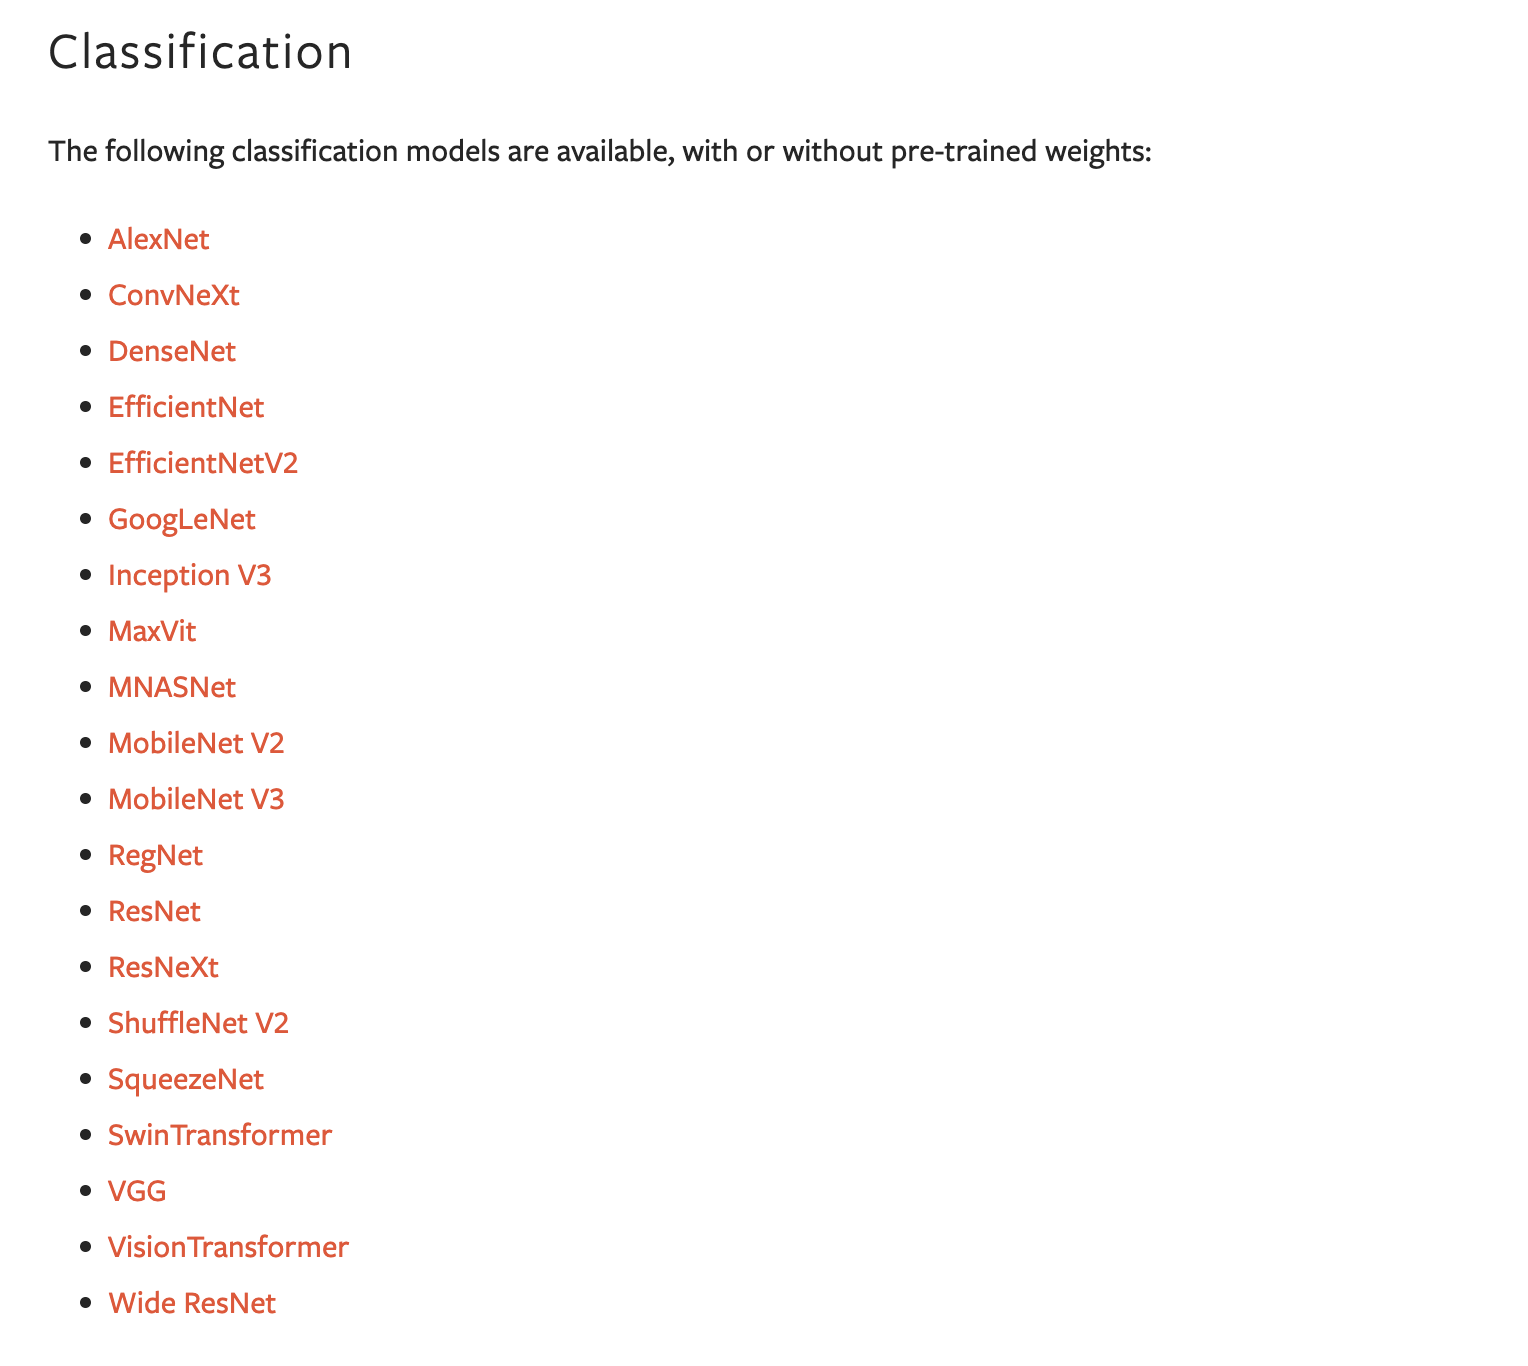

ПОсмотрим на бэнчмарикнг, чтобы выбрать наиболее сильную для нас:

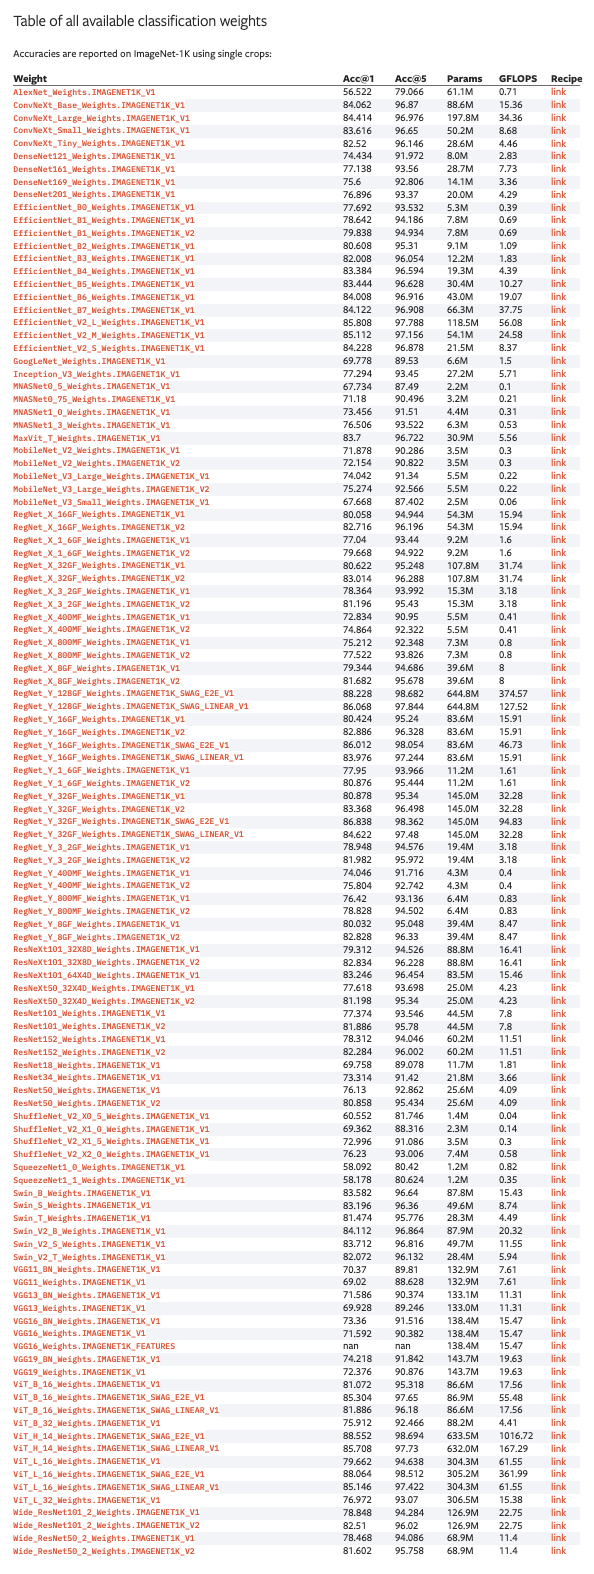

Среди всех предложенных моделей мы не можем просто тупо взять самую сильную и дообучать её. Потому что мы ограничены вычислительными мощностями, памятью. Из тех, что нам подходят наиболее всего (по вышеперечисленным причинам), выделим топ 5:

| Модель           |       Acc@1 | Параметры | GFLOPS |
| ---------------- | ----------: | --------: | -----: |
| EfficientNetV2-S | 84,228% |  21,5 млн |   8,37 |
| Swin V2-B        |     84,112% |  87,9 млн |  20,32 |
| ConvNeXt-Base    | 84,062% |  88,6 млн |  15,36 |
| ConvNeXt-Small   |     83,616% |  50,2 млн |   8,68 |
| ConvNeXt-Tiny    |     82,520% |  28,6 млн |   4,46 |


Самым оптимальным выбором тут является EfficientNetV2-S, но она рассчитана принимать на вход более крупыне изображения, чем 224 на 224, а у нас они имеют именно такой размер. Потом идёт Swin V2-B, но она требует слишком много вычислительных ресурсов. Потом ConvNeXt-Base, но тоже многовато. Потом ConvNeXt-Small - вот её и возьмём

### Как будем обучать ConvNeXt-Small

Мы будем обучать ConvNeXt-Small, для этого загрузим ConvNeXt-Small с готовыми весами, полученными при обучении.

Последний слой исходной модели рассчитан на 1000 классов, поэтому мы заменим его на новый классификатор для двух классов (fire и nofire)

Обучение будем производить в два этапа:
1. Сначала заморозим основную часть модели и обучим только новый классификатор. На этом этапе готовые признаки мы оставим без изменений и новый слой научим использовать их для определения пожара.
2. Затем разморозим последний блок модели и продолжим обучение с небольшим learning rate. Это позволит адаптировать наиболее сложные признаки именно под изображения из нашего датасета.
Мы также добавим небольшие случайные преобразования изображений для обучающей выборки (отражение, поворот и изменение масштаба), что поможет увеличить разнообразию данных и снизить риск переобучения. Для валидационной и тестовой выборок мы случайные преобразования не используем.

Для изображений мы будем использовать ту же нормализацию, которая применялась при её первоначальном обучении.

Качество будем оценивать по Accuracy, Precision, Recall и F1-score для класса fire . Лучшие веса будем сохранять по максимальному значению F1-score на валидационной выборке.

In [ ]:
import shutil
from torchvision.models import ConvNeXt_Small_Weights

convnext_weights = ConvNeXt_Small_Weights.DEFAULT

local_data_dir = '/content/wildfire_dataset_224'

if not os.path.exists(local_data_dir): shutil.copytree(resized_data_dir, local_data_dir)

local_train_dir = os.path.join(local_data_dir, 'train')
local_val_dir = os.path.join(local_data_dir, 'val')
local_test_dir = os.path.join(local_data_dir, 'test')


# нормализация imagenet с которой обучалась convnext
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]


# так как у нас достаточно небольшой датасет, для добавим аугментацию
transfer_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=224, scale=(0.9, 1.0)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)])


transfer_eval_transform = convnext_weights.transforms()


# создаём отдельные датасеты для
transfer_train_dataset = datasets.ImageFolder(local_train_dir, transform=transfer_train_transform)
transfer_val_dataset = datasets.ImageFolder(local_val_dir, transform=transfer_eval_transform)
transfer_test_dataset = datasets.ImageFolder(local_test_dir, transform=transfer_eval_transform)

transfer_batch_size = 16
transfer_num_workers = 2


# создаём отдельные DataLoader
transfer_train_loader = DataLoader(
    transfer_train_dataset,
    batch_size=transfer_batch_size,
    shuffle=True,
    num_workers=transfer_num_workers,
    pin_memory=True,
    persistent_workers=True)

transfer_val_loader = DataLoader(
    transfer_val_dataset,
    batch_size=transfer_batch_size,
    shuffle=False,
    num_workers=transfer_num_workers,
    pin_memory=True,
    persistent_workers=True)

transfer_test_loader = DataLoader(
    transfer_test_dataset,
    batch_size=transfer_batch_size,
    shuffle=False,
    num_workers=transfer_num_workers,
    pin_memory=True,
    persistent_workers=True)


print('Train:', len(transfer_train_dataset))
print('Validation:', len(transfer_val_dataset))
print('Test:', len(transfer_test_dataset))
print('Классы:', transfer_train_dataset.class_to_idx)

images, labels = next(iter(transfer_train_loader))

print('Размер батча:', images.shape)
print('Размер меток:', labels.shape)

Train: 1887
Validation: 402
Test: 410
Классы: {'fire': 0, 'nofire': 1}
Размер батча: torch.Size([16, 3, 224, 224])
Размер меток: torch.Size([16])


In [ ]:
#загружаем модель
convnext_model = convnext_small(weights=convnext_weights)

Downloading: "https://download.pytorch.org/models/convnext_small-0c510722.pth" to /root/.cache/torch/hub/checkpoints/convnext_small-0c510722.pth


100%|██████████| 192M/192M [00:01<00:00, 120MB/s]


### V1

In [ ]:
# замораживаем все предобученные параметры модели
for parameter in convnext_model.parameters(): parameter.requires_grad = False

# меняем количество признаков на выходе под наше число классов
in_features = convnext_model.classifier[2].in_features
convnext_model.classifier[2] = nn.Sequential(nn.Dropout(0.3), nn.Linear(in_features, 2))

convnext_model.run_name = 'convnext_small_frozen'

convnext_model.model_config = {
    'model': 'ConvNeXt-Small',
    'pretrained_weights': 'ImageNet1K_V1',
    'training_stage': 'frozen_backbone',
    'backbone_frozen': True,
    'dropout': 0.3,
    'num_classes': 2}


# посмотрим на количество параметров
total_parameters = sum(parameter.numel() for parameter in convnext_model.parameters())
trainable_parameters = sum(parameter.numel() for parameter in convnext_model.parameters() if parameter.requires_grad)

print('Всего параметров:', total_parameters)
print('Обучаемых параметров:', trainable_parameters)
print('Классификатор:')
print(convnext_model.classifier)

Всего параметров: 49456226
Обучаемых параметров: 1538
Классификатор:
Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=768, out_features=2, bias=True)
  )
)


Сначала обучим только новый классификатор, а основную часть модели оставим замороженной. Так модель сохранит уже выученные признаки изображений, а новый слой научится разделять наши два класса: fire и nofire

Так как обучается только небольшая часть модели, на этом этапе будет достаточно 5 эпох:


In [ ]:
CFG.num_epochs =5
CFG.lr= 1e-3
CFG.weight_decay = 1e-4

convnext_frozen_model, convnext_frozen_history = run_experiment(convnext_model, experiment_train_loader=transfer_train_loader, experiment_val_loader=transfer_val_loader)

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.



Epoch: 1


100%|██████████| 118/118 [00:17<00:00,  6.57it/s]


Train set: Average loss: 0.3750, Accuracy: 83.09%


Validation set: Loss: 0.3053, Accuracy: 87.31%, Precision fire: 0.8477, Recall fire: 0.8205, F1 fire: 0.8339

Epoch: 2


...


Train set: Average loss: 0.2543, Accuracy: 90.25%
Validation set: Loss: 0.2393, Accuracy: 90.05%, Precision fire: 0.9143, Recall fire: 0.8205, F1 fire: 0.8649

Epoch: 5


100%|██████████| 118/118 [00:15<00:00,  7.71it/s]



Train set: Average loss: 0.2465, Accuracy: 90.25%
Validation set: Loss: 0.2489, Accuracy: 90.05%, Precision fire: 0.9265, Recall fire: 0.8077, F1 fire: 0.8630


epoch,▁▃▅▆█
learning_rate,▁▁▁▁▁
train_accuracy,▁▆▆██
train_loss,█▄▃▁▁
val_accuracy,▁▆▇██
val_f1_fire,▁▆▇██
val_loss,█▄▂▁▂
val_precision_fire,▁▄▇▇█
val_recall_fire,▅█▃▅▁
best_epoch,4
best_val_accuracy,0.9005



Training is ended! 
Best epoch by F1 fire: 4 
Validation loss: 0.2393 
Accuracy: 90.05 % 
Precision fire: 0.9143 
Recall fire: 0.8205 
F1 fire: 0.8649


На первом этапе мы заморозили основную часть модели и обучали только новый классификатор для двух классов.

Даже без дообучения всей модели результат стал заметно лучше, чем у моделей, обученных с нуля. Лучший F1 score для класса fire составил 0,86486, accuracy — 90,20%.


Следующим шагом разморозим последний блок convnext и проведём fine tuning с маленьким lr

### V2

Ранние слои модели оставим замороженными, потому что они отвечают за базовые признаки изображений. Последний блок содержит более сложные признаки, поэтому его можно аккуратно адаптировать под наш датасет.

Lr сделаем меньше чем на первом этапе, чтобы не испортить уже обученные веса модели:

In [ ]:
#размораживаем последний блок и классификптор
for parameter in convnext_frozen_model.features[-1].parameters(): parameter.requires_grad = True
for parameter in convnext_frozen_model.classifier.parameters(): parameter.requires_grad = True

convnext_frozen_model.run_name = 'convnext_small_finetuning'

convnext_frozen_model.model_config.update({
    'training_stage': 'fine_tuning_last_block',
    'backbone_frozen': 'partially',
    'unfrozen_part': 'features[-1] and classifier'})


# посмотрим на количество параметров
total_parameters = sum(parameter.numel() for parameter in convnext_frozen_model.parameters())
trainable_parameters = sum(parameter.numel() for parameter in convnext_frozen_model.parameters() if parameter.requires_grad)

print('Всего параметров:', total_parameters)
print('Обучаемых параметров:', trainable_parameters)

Всего параметров: 49456226
Обучаемых параметров: 14292482


In [ ]:
CFG.num_epochs =10
CFG.lr= 1e-5
CFG.weight_decay = 1e-4

convnext_finetuned_model, convnext_finetuned_history = run_experiment(convnext_frozen_model, experiment_train_loader=transfer_train_loader, experiment_val_loader=transfer_val_loader)


Epoch: 1


100%|██████████| 118/118 [00:18<00:00,  6.24it/s]



Train set: Average loss: 0.2331, Accuracy: 90.62%
Validation set: Loss: 0.2322, Accuracy: 90.55%, Precision fire: 0.9155, Recall fire: 0.8333, F1 fire: 0.8725

Epoch: 2


100%|██████████| 118/118 [00:19<00:00,  6.19it/s]



Train set: Average loss: 0.2411, Accuracy: 89.83%
Validation set: Loss: 0.2320, Accuracy: 90.80%, Precision fire: 0.9161, Recall fire: 0.8397, F1 fire: 0.8763

Epoch: 3


...


Train set: Average loss: 0.1786, Accuracy: 92.53%
Validation set: Loss: 0.2235, Accuracy: 91.29%, Precision fire: 0.8805, Recall fire: 0.8974, F1 fire: 0.8889

Epoch: 10


100%|██████████| 118/118 [00:18<00:00,  6.23it/s]



Train set: Average loss: 0.1857, Accuracy: 91.89%
Validation set: Loss: 0.2157, Accuracy: 92.54%, Precision fire: 0.9315, Recall fire: 0.8718, F1 fire: 0.9007


epoch,▁▂▃▃▄▅▆▆▇█
learning_rate,▁▁▁▁▁▁▁▁▁▁
train_accuracy,▃▁▃▃▄▅▇██▆
train_loss,▇█▇▆▆▃▃▂▁▂
val_accuracy,▁▂▁▆▇▅▅█▃▇
val_f1_fire,▁▂▁▆▇▅▆█▄▇
val_loss,███▄▄▃▂▁▄▁
val_precision_fire,▆▆▇▇▇▇▅█▁█
val_recall_fire,▂▃▁▆▆▅▆▇█▆
best_epoch,8
best_val_accuracy,0.93035



Training is ended! 
Best epoch by F1 fire: 8 
Validation loss: 0.2163 
Accuracy: 93.03 % 
Precision fire: 0.9324 
Recall fire: 0.8846 
F1 fire: 0.9079


**Вывод**

Лучший результат был получен на 9-й эпохе:

Accuracy — 93,035%

Precision — 0,9324

Recall — 0,8846

F1 score — 0,9079

По сравнению с первым этапом F1 увеличился с 0,86486 до 0,9079

Разница между accuracy на тренировочной и валидационной выборке совсем минимальна. Это говорит о том, что с проблемой переообучения мы не сталкиваемся. И скорее всего даже не исчерпали весь потенциал нашей модели.


### V3

Попробуем уменьшить lr и разморозить некоторую часть ещё и предпоследнего блока:

In [ ]:
# Сначала снова замораживаем всю модель
for parameter in convnext_extended_model.parameters(): parameter.requires_grad = False

stage3 = convnext_extended_model.features[5] # 3й блок
stage4 = convnext_extended_model.features[7] # 4йблок

# разморозим последние 6 блоков 3 блока
for block in stage3[-6:]:
  for parameter in block.parameters(): parameter.requires_grad = True

for parameter in stage4.parameters(): parameter.requires_grad = True
for parameter in convnext_extended_model.classifier.parameters(): parameter.requires_grad = True


convnext_extended_model.run_name = 'convnext_small_extended_finetuning'
convnext_extended_model.model_config.update({
    'training_stage': 'extended_fine_tuning',
    'unfrozen_stage3_blocks': 6,
    'stage4_unfrozen': True,
    'classifier_unfrozen': True})


total_parameters = sum(parameter.numel() for parameter in convnext_extended_model.parameters())
trainable_parameters = sum(parameter.numel() for parameter in convnext_extended_model.parameters() if parameter.requires_grad)

print('Блоков в Stage 3:', len(stage3))
print('Блоков в Stage 4:', len(stage4))
print('Всего параметров:', total_parameters)
print('Обучаемых параметров:', trainable_parameters)
print('Доля обучаемых параметров:', round(trainable_parameters/total_parameters *100, 2), '%')

Блоков в Stage 3: 27
Блоков в Stage 4: 3
Всего параметров: 49456226
Обучаемых параметров: 21504002
Доля обучаемых параметров: 43.48 %


In [ ]:
CFG.num_epochs = 10
CFG.lr = 5e-6
CFG.weight_decay = 1e-4

seed_everything(CFG.seed)

convnext_extended_model, convnext_extended_history = run_experiment(convnext_extended_model, experiment_train_loader=transfer_train_loader, experiment_val_loader=transfer_val_loader)


Epoch: 1


100%|██████████| 118/118 [00:26<00:00,  4.53it/s]



Train set: Average loss: 0.1933, Accuracy: 92.16%
Validation set: Loss: 0.2151, Accuracy: 92.04%, Precision fire: 0.9079, Recall fire: 0.8846, F1 fire: 0.8961

Epoch: 2


100%|██████████| 118/118 [00:26<00:00,  4.41it/s]



Train set: Average loss: 0.1800, Accuracy: 93.16%
Validation set: Loss: 0.2119, Accuracy: 92.04%, Precision fire: 0.9026, Recall fire: 0.8910, F1 fire: 0.8968

Epoch: 3


...


Train set: Average loss: 0.1542, Accuracy: 93.80%
Validation set: Loss: 0.2019, Accuracy: 93.03%, Precision fire: 0.9267, Recall fire: 0.8910, F1 fire: 0.9085

Epoch: 10


100%|██████████| 118/118 [00:25<00:00,  4.64it/s]



Train set: Average loss: 0.1421, Accuracy: 95.07%
Validation set: Loss: 0.2010, Accuracy: 93.03%, Precision fire: 0.9324, Recall fire: 0.8846, F1 fire: 0.9079


epoch,▁▂▃▃▄▅▆▆▇█
learning_rate,▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▃▃▄▂▅▅▅▅█
train_loss,█▆▆▅▆▃▂▃▃▁
val_accuracy,▃▃▁▃▃▇▆█▆▆
val_f1_fire,▂▃▁▃▃▇▆█▆▆
val_loss,█▆▆█▄▆▄▆▁▁
val_precision_fire,▃▂▁▅▂▇▅█▅▅
val_recall_fire,▆██▁█▃▆▃█▆
best_epoch,8
best_val_accuracy,0.93781



Training is ended! 
Best epoch by F1 fire: 8 
Validation loss: 0.2108 
Accuracy: 93.78 % 
Precision fire: 0.958 
Recall fire: 0.8782 
F1 fire: 0.9164


Лучший результат получили на 8 эпохе

Accuracy — 93,781%

Precision fire — 0,95804

Recall fire — 0,87821

F1 fire — 0,9164

Уже лучше, но попробуем улучшить ещё:

### V4

увеличим lr в 10 раз:

In [ ]:
CFG.num_epochs = 10
CFG.lr = 5e-5
CFG.weight_decay = 1e-4

seed_everything(CFG.seed)

convnext_extended_model, convnext_extended_history = run_experiment(convnext_extended_model, experiment_train_loader=transfer_train_loader, experiment_val_loader=transfer_val_loader)


Epoch: 1


100%|██████████| 118/118 [00:25<00:00,  4.62it/s]



Train set: Average loss: 0.1591, Accuracy: 94.01%
Validation set: Loss: 0.1989, Accuracy: 93.03%, Precision fire: 0.9103, Recall fire: 0.9103, F1 fire: 0.9103

Epoch: 2


100%|██████████| 118/118 [00:26<00:00,  4.50it/s]



Train set: Average loss: 0.1297, Accuracy: 95.23%
Validation set: Loss: 0.1930, Accuracy: 94.03%, Precision fire: 0.9583, Recall fire: 0.8846, F1 fire: 0.9200

Epoch: 3


...


Train set: Average loss: 0.0557, Accuracy: 98.25%
Validation set: Loss: 0.2083, Accuracy: 93.53%, Precision fire: 0.9514, Recall fire: 0.8782, F1 fire: 0.9133

Epoch: 10


100%|██████████| 118/118 [00:26<00:00,  4.43it/s]



Train set: Average loss: 0.0514, Accuracy: 98.36%
Validation set: Loss: 0.2078, Accuracy: 94.03%, Precision fire: 0.9583, Recall fire: 0.8846, F1 fire: 0.9200


epoch,▁▂▃▃▄▅▆▆▇█
learning_rate,██████▁▁▁▁
train_accuracy,▁▃▄▅▅▆▇▇██
train_loss,█▆▅▄▄▃▂▂▁▁
val_accuracy,▁█▁▃▆▃▄▁▄█
val_f1_fire,▃█▁▃▆▂▅▁▅█
val_loss,▂▁▃▂▃█▁▃▃▃
val_precision_fire,▁▇▅▄▇█▅▆▆▇
val_recall_fire,█▅▃▅▄▁▅▃▄▅
best_epoch,2
best_val_accuracy,0.9403



Training is ended! 
Best epoch by F1 fire: 2 
Validation loss: 0.193 
Accuracy: 94.03 % 
Precision fire: 0.9583 
Recall fire: 0.8846 
F1 fire: 0.92


Увеличение lr позволило немного улучшить результат. Максимальный F1 score получился 0,92, accuracy 94,03%

А после второй эпохи видим, как наша модель начала переобучаться уже. Остановимся на этом результате

### Подбор порога

По умолчанию модель относит изображения к классу fire, если вероятность этого класса выше 0,5. Переберем разные пороги на валидационной выборке и выберем тот, для которого F1-score для класса fire будет наилучшим. Веса модели при этом не изменяются

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
convnext_extended_model.eval()

y_true, fire_probs = [], []

with torch.no_grad():
  for i, l in transfer_val_loader:
    outs = convnext_extended_model(i.to(device))
    fire_probs.extend(torch.softmax(outs, dim = 1)[:, 0].cpu().numpy())
    y_true.extend(l.numpy())

y_true = np.array(y_true)
fire_probs = np.array(fire_probs)

In [ ]:
best_threshold, best_f1 = 0.5, 0

treshs = np.arange(0.1, 0.91, 0.01)

for t in threhs:
  condition = (fire_probs >= t)
  y_pred = np.where(condition, 0, 1)
  f1_t = f1_score(y_true, y_pred, pos_label = 0) # pos_label = 0 так как класс огня - 0

  if f1_t > best_f1:
    best_threshold = t
    best_f1 = f1_t
    best_predictions = y_pred

print('Лучший порог:', best_threshold.round(2), '\n')
print(f'Accuracy: {round(accuracy score(y_true, best_predictions)) * 100, 2}'),
print(f'Precision: {round(precision_score(y_true, best_predictions, pos_label = 0), 4)}')
print(f'Recall:, {round(recall_score(y_true, best_predictions, pos_label = 0), 4)}')
print(f'F1: {best_f1.round(4)}')

Лучший порог: 0.46
Accuracy: 94.28 %
Precision fire: 0.9586
Recall fire: 0.891
F1 fire: 0.9236


так, ну мы немного улучшили наши результаты, уже хорошо. Попробуем запустить нашу модель по тестовой выборке с новым порогом

In [ ]:
best_threshold = 0.46

convnext_extended_model = convnext_extended_model.to(device)
convnext_extended_model.eval()

test_true, test_fire_probs = [], []

with torch.no_grad() :
  for i, l in transfer_test_loader:

    outs = convnext_extended_model(i.to(device))
    fire_probs = torch.softmax(outs, dim = 1) [:, 0]
    test_fire_probs.extend(fire_probs.cpu().numpy())
    test_true.extend(l.numpy())


test_true = np.array(test_true)
test_fire_probs = np.array(test_fire_probs)

condition = test_fire_probs >= best_threshold
test_pred = np.where(condition, 0, 1) # fire - 0 и nofire - 1

acc = accuracy_score(test_true, test_pred)
prec = precision_score(test_true, test_pred, pos_label = 0)
rec = recall_score(test_true, test_pred, pos_label = 0)
f1 = f1_score(test_true, test_pred, pos_label = 0)

print(f'Accuracy на тест:, {acc.round(4)}')
print(f'Precision на тест:, {prec.round(4)}')
print(f'Recall на тест:, {rec.round(4)}')
print(f'F1 на тест:, {f1.round(4)}')

Test Accuracy: 95.37 %
Test Precision fire: 0.9487
Test Recall fire: 0.9308
Test F1 fire: 0.9397


Модель правильно классифицирует большую часть изображений и обнаруживает около 93% изображений с пожаром. Высокие значения Precision и Recall показывают, что модель одновременно редко пропускает пожары и не создаёт слишком много ложных срабатываний.

Итоговый результат подтверждает, что transfer learning с ConvNeXt-Small значительно улучшил качество по сравнению с моделями, которые обучались с нуля.